In [1]:
import numpy as np

X = np.load("../data/X.npy")
y = np.load("../data/y.npy")

print(X.shape)
print(np.unique(y, return_counts=True))

(29, 64, 801)
(array([1, 2, 3]), array([14,  7,  8]))


In [2]:
mask = (y == 2) | (y == 3)

X_bin = X[mask]
y_bin = y[mask]

print(X_bin.shape)
print(np.unique(y_bin, return_counts=True))

(15, 64, 801)
(array([2, 3]), array([7, 8]))


In [3]:

y_bin = np.where(y_bin == 2, 0, 1)
print(np.unique(y_bin, return_counts=True))

(array([0, 1]), array([7, 8]))


In [4]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

clf = Pipeline([
    ("csp", CSP(n_components=4, log=True, norm_trace=False)),
    ("lda", LinearDiscriminantAnalysis())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Computing rank from data with rank=None
    Using tolerance 0.00017 (2.2e-16 eps * 64 dim * 1.2e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Accuracy: 1.0
Confusion matrix:
 [[2 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [5]:
csp = clf.named_steps["csp"]
csp.plot_patterns(info=None)

NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


AttributeError: 'NoneType' object has no attribute '_unlock'

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")
print("CV scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [7]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")

print("Scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())
print("Min:", scores.min())
print("Max:", scores.max())

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [8]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, pvalue = permutation_test_score(
    clf,
    X_bin,
    y_bin,
    cv=5,
    n_permutations=200,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

print("Real score:", score)
print("Permutation mean:", perm_scores.mean())
print("p-value:", pvalue)

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [10]:
X = np.load("../data/X.npy")
y = np.load("../data/y.npy")

In [11]:
X = np.load("../data/X_5sec.npy")
y = np.load("../data/y_5sec.npy")

In [12]:
X = np.load("../data/X_2sec.npy")
y = np.load("../data/y_2sec.npy")

In [13]:
print(type(X), X.shape)
print(type(y), y.shape)
print(np.unique(y, return_counts=True))

<class 'numpy.ndarray'> (30, 64, 321)
<class 'numpy.ndarray'> (30,)
(array([1, 2, 3]), array([15,  7,  8]))


In [14]:
sfreq = 160
print("Seconds per epoch:", X.shape[2] / sfreq)

Seconds per epoch: 2.00625


In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")

print("Scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())
print("Min:", scores.min())
print("Max:", scores.max())

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [17]:
from sklearn.model_selection import StratifiedKFold

for seed in [1, 7, 21, 42, 77, 123]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")
    print(f"seed={seed} -> mean={scores.mean():.3f}, std={scores.std():.3f}, scores={scores}")

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [16]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, pvalue = permutation_test_score(
    clf,
    X_bin,
    y_bin,
    cv=5,
    n_permutations=200,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

print("Real score:", score)
print("Permutation mean:", perm_scores.mean())
print("p-value:", pvalue)

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [18]:
X = np.load("../data/X_multi.npy")
y = np.load("../data/y_multi.npy")

In [19]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")

print("Scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())
print("Min:", scores.min())
print("Max:", scores.max())

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [20]:
from sklearn.model_selection import permutation_test_score

score, perm_scores, pvalue = permutation_test_score(
    clf,
    X_bin,
    y_bin,
    cv=5,
    n_permutations=200,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

print("Real score:", score)
print("Permutation mean:", perm_scores.mean())
print("p-value:", pvalue)

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [21]:
from sklearn.model_selection import StratifiedKFold

for seed in [1, 7, 21, 42, 77, 123]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(clf, X_bin, y_bin, cv=cv, scoring="accuracy")
    print(f"seed={seed} -> mean={scores.mean():.3f}, std={scores.std():.3f}, scores={scores}")

Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMP

In [22]:
X = np.load("../data/X_multi.npy")
y = np.load("../data/y_multi.npy")

In [23]:
import numpy as np

print(X.shape)
print(y.shape)
print(np.unique(y, return_counts=True))

mask = (y == 2) | (y == 3)
X_bin = X[mask]
y_bin = y[mask]

y_bin = np.where(y_bin == 2, 0, 1)

print(X_bin.shape)
print(np.unique(y_bin, return_counts=True))

(90, 64, 321)
(90,)
(array([1, 2, 3]), array([45, 21, 24]))
(45, 64, 321)
(array([0, 1]), array([21, 24]))


In [24]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [25]:
pipelines = {
    "CSP + LDA": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    
    "CSP + SVM": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", SVC(kernel="linear"))
    ]),
    
    "CSP + LogReg": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
}

In [26]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

results = {}

for name, model in pipelines.items():
    scores = cross_val_score(model, X_bin, y_bin, cv=cv, scoring="accuracy")
    results[name] = scores
    
    print(f"\n{name}")
    print("Mean accuracy:", scores.mean())
    print("Std:", scores.std())
    print("Min:", scores.min())
    print("Max:", scores.max())

In [ ]:
result_logreg = {
    "model": "CSP + Logistic Regression",
    "subject": 1,
    "runs": [6, 10, 14],
    "channels": 64,
    "time_window_sec": [0.5, 2.5],
    "frequency_band_hz": [8, 30],
    "classes": "T1 vs T2",
    "epochs_after_binary_filter": int(len(y_bin)),
    "cv": "RepeatedStratifiedKFold",
    "n_splits": 5,
    "n_repeats": 10,
    "random_state": 42,
    "mean_accuracy": float(scores.mean()),
    "std_accuracy": float(scores.std()),
    "min_accuracy": float(scores.min()),
    "max_accuracy": float(scores.max()),
}
result_logreg

In [1]:
import json
import os

os.makedirs("../outputs", exist_ok=True)

with open("../outputs/result_logreg.json", "w", encoding="utf-8") as f:
    json.dump(result_logreg, f, indent=4, ensure_ascii=False)

print("Saved to ../outputs/result_logreg.json")

NameError: name 'result_logreg' is not defined

import numpy as np

X = np.load("../data/X_multi.npy")
y = np.load("../data/y_multi.npy")

print(X.shape)
print(y.shape)
print(np.unique(y, return_counts=True))


In [1]:
import numpy as np

X = np.load("../data/X_multi.npy")
y = np.load("../data/y_multi.npy")

print(X.shape)
print(y.shape)
print(np.unique(y, return_counts=True))


(90, 64, 321)
(90,)
(array([1, 2, 3]), array([45, 21, 24]))


In [2]:
mask = (y == 2) | (y == 3)

X_bin = X[mask]
y_bin = y[mask]

y_bin = np.where(y_bin == 2, 0, 1)

print(X_bin.shape)
print(np.unique(y_bin, return_counts=True))


(45, 64, 321)
(array([0, 1]), array([21, 24]))


In [3]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [4]:
pipelines = {
    "CSP + LDA": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    
    "CSP + SVM": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", SVC(kernel="linear"))
    ]),
    
    "CSP + LogReg": Pipeline([
        ("csp", CSP(n_components=4, log=True, norm_trace=False)),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
}


In [5]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

In [6]:
results = {}

for name, model in pipelines.items():
    scores = cross_val_score(model, X_bin, y_bin, cv=cv, scoring="accuracy")
    results[name] = scores
    
    print(f"\n{name}")
    print("Mean accuracy:", scores.mean())
    print("Std:", scores.std())
    print("Min:", scores.min())
    print("Max:", scores.max())

Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIR

In [7]:
import pandas as pd

summary = []

for name, scores in results.items():
    summary.append({
        "Model": name,
        "Mean accuracy": scores.mean(),
        "Std": scores.std(),
        "Min": scores.min(),
        "Max": scores.max(),
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values(by="Mean accuracy", ascending=False)

summary_df

,Model,Mean accuracy,Std,Min,Max
0,CSP + LDA,0.971111,0.057991,0.777778,1.0
1,CSP + SVM,0.968889,0.058962,0.777778,1.0
2,CSP + LogReg,0.968889,0.058962,0.777778,1.0


In [8]:
import os

os.makedirs("../outputs", exist_ok=True)
summary_df.to_csv("../outputs/model_comparison.csv", index=False)

print("Saved to ../outputs/model_comparison.csv")

Saved to ../outputs/model_comparison.csv


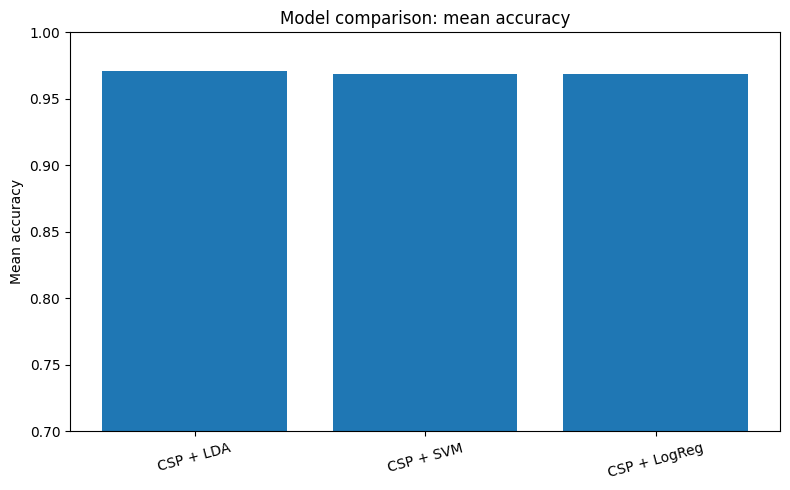

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Mean accuracy"])
plt.ylim(0.7, 1.0)
plt.ylabel("Mean accuracy")
plt.title("Model comparison: mean accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

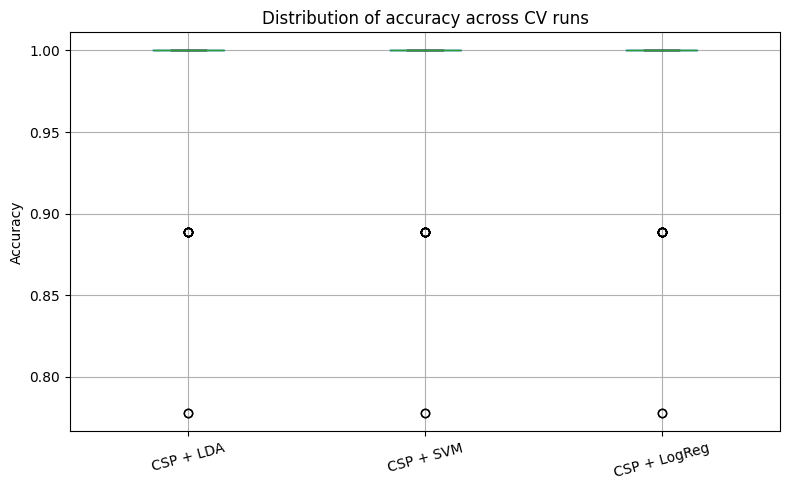

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

plot_data = pd.DataFrame({
    model_name: scores for model_name, scores in results.items()
})

plt.figure(figsize=(8, 5))
plot_data.boxplot()
plt.ylabel("Accuracy")
plt.title("Distribution of accuracy across CV runs")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [11]:
import os

os.makedirs("../outputs", exist_ok=True)

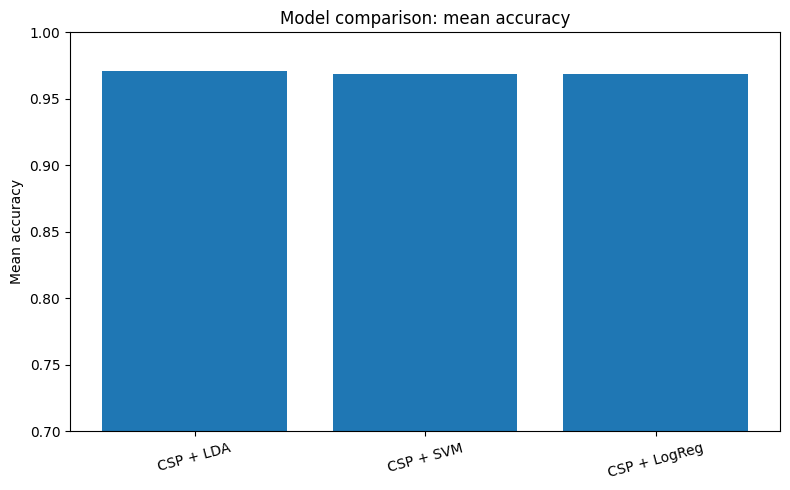

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Mean accuracy"])
plt.ylim(0.7, 1.0)
plt.ylabel("Mean accuracy")
plt.title("Model comparison: mean accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/model_mean_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

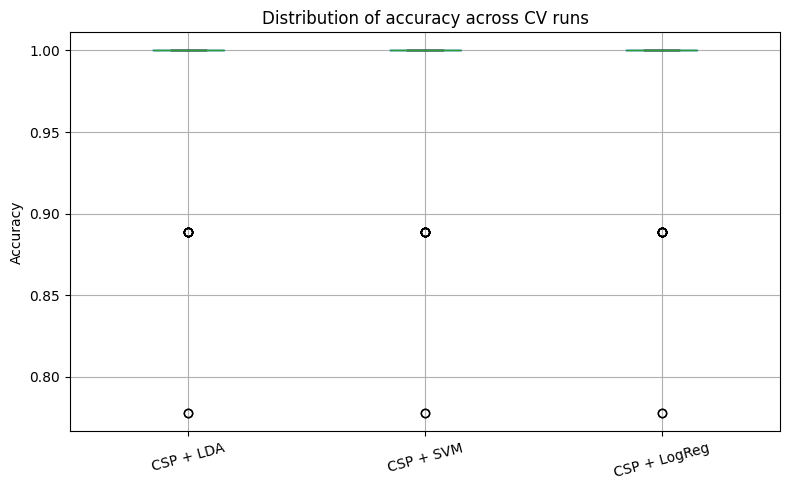

In [13]:
plt.figure(figsize=(8, 5))
plot_data.boxplot()
plt.ylabel("Accuracy")
plt.title("Distribution of accuracy across CV runs")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/model_accuracy_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
os.listdir("../outputs")

['model_comparison.csv',
 'result_logreg.json',
 'model_mean_accuracy.png',
 'model_accuracy_boxplot.png',
 '.ipynb_checkpoints',
 'result_logreg_CSP_Logistic Regression.json']

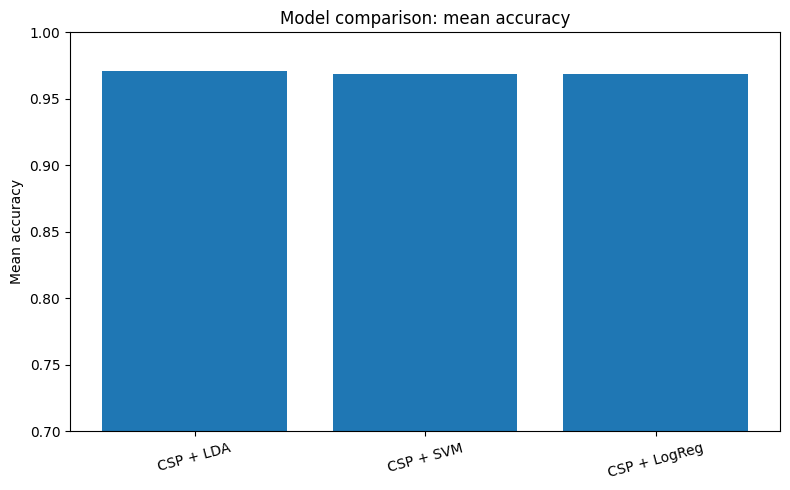

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(summary_df["Model"], summary_df["Mean accuracy"])
plt.ylim(0.7, 1.0)
plt.ylabel("Mean accuracy")
plt.title("Model comparison: mean accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/model_mean_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

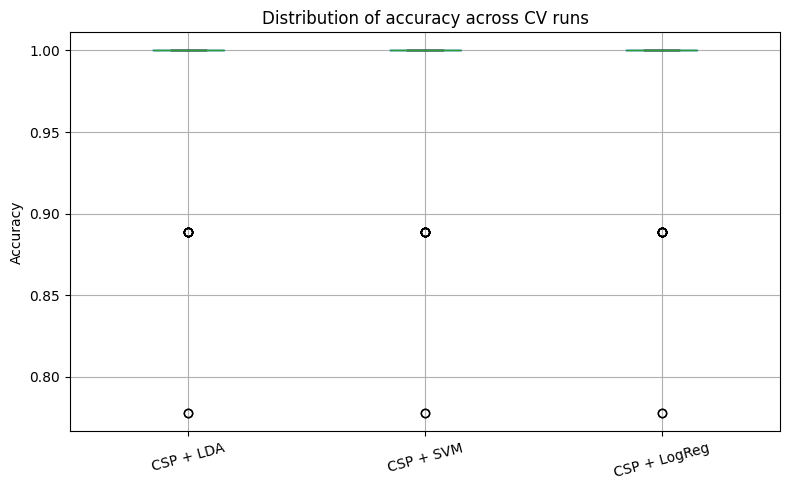

In [16]:
import pandas as pd

plot_data = pd.DataFrame({
    model_name: scores for model_name, scores in results.items()
})

plt.figure(figsize=(8, 5))
plot_data.boxplot()
plt.ylabel("Accuracy")
plt.title("Distribution of accuracy across CV runs")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/model_accuracy_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
os.listdir("../outputs")

['model_comparison.csv',
 'result_logreg.json',
 'model_mean_accuracy.png',
 'model_accuracy_boxplot.png',
 '.ipynb_checkpoints',
 'result_logreg_CSP_Logistic Regression.json']

In [18]:
report_text = """
EEG Motor Imagery Decoding with Classical Machine Learning

1. Objective
The goal of this project was to test whether two different motor imagery states can be distinguished from EEG brain signals using a classical brain-computer interface pipeline.

2. Data
The project used real multichannel EEG recordings from the EEGBCI dataset.
The analysis was performed in a subject-specific setup using one subject and three runs.

3. Preprocessing
The raw EEG signals were segmented into epochs using event markers.
A band-pass filter of 8–30 Hz was applied to isolate the frequency range relevant to motor imagery.
The time window 0.5–2.5 s after the event was used for classification.

4. Methods
The task was reduced to binary classification between two motor imagery classes (T1 vs T2).
Common Spatial Patterns (CSP) were used for feature extraction.
Three classifiers were compared:
- LDA
- SVM
- Logistic Regression

5. Evaluation
Performance was evaluated using repeated stratified cross-validation.
Additional validation included permutation testing to confirm that the result was not random.

6. Results
All three models achieved high performance.
The best result was obtained with CSP + LDA, with mean accuracy around 97.1%.
SVM and Logistic Regression performed nearly identically, with only a very small difference from LDA.

7. Conclusion
The results show that subject-specific motor imagery states can be reliably decoded from EEG data using a classical BCI pipeline.
This project demonstrates a practical baseline for EEG signal decoding and serves as a foundation for future work in brain-computer interfaces and neurotechnology.
"""

with open("../outputs/project_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved to ../outputs/project_report.txt")

Saved to ../outputs/project_report.txt
